# 🧠 MAE Pretraining for Medical Image Segmentation
## BraTS Edition — ResUNet Fine-tuning

Complete pipeline: **MAE self-supervised pretraining** → **ResUNet fine-tuning** on BraTS brain-tumour segmentation.

> ⚠️ **BraTS data is required.** If the dataset cannot be loaded the notebook raises an error and stops — no synthetic fallback is used.

**Pipeline:**
1. 📦 Environment Setup & Imports
2. ⚙️ Configuration
3. 🗂️ Dataset Loading — BraTS only
4. 🔄 Medical Augmentations
5. 🟠 MAE Pretraining
6. 🎯 ResUNet Fine-Tuning (ResNet34 Encoder + U-Net Decoder)
7. 📊 Evaluation (Dice, IoU, Hausdorff)
8. 📈 Results & Visualizations


---
## 1. 📦 Environment Setup & Imports

In [8]:
# Install required packages (run once)
import subprocess, sys

packages = [
    'torch', 'torchvision', 'timm',
    'nibabel',
    'scipy',
    'scikit-learn',
    'pyyaml',
    'matplotlib',
    'numpy',
    'tqdm',
    'einops',
    'monai',
]

for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All packages installed.')


✅ All packages installed.

⏱️  Cell executed in 5.54s


In [9]:
# ── Core imports ─────────────────────────────────────────────────────────────
import os, math, copy, random, yaml, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import List, Optional, Tuple, Dict

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm

# ── PyTorch ──────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms

# ── Medical imaging ──────────────────────────────────────────────────────────
import nibabel as nib

# ── Timm / einops ────────────────────────────────────────────────────────────
import timm
from einops import rearrange, repeat

# ── MONAI ────────────────────────────────────────────────────────────────────
try:
    from monai.transforms import (
        RandGaussianNoise, RandBiasField, RandGibbsNoise,
        RandKSpaceSpikeNoise, NormalizeIntensity, ScaleIntensityRange
    )
    MONAI_AVAILABLE = True
except ImportError:
    MONAI_AVAILABLE = False
    print('⚠️  MONAI not available — using custom augmentations.')

warnings.filterwarnings('ignore')

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'🖥️  Device: {DEVICE}')

# ── Reproducibility ──────────────────────────────────────────────────────────
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)
torch.backends.cudnn.benchmark = True
print('✅ Imports done.')


🖥️  Device: mps
✅ Imports done.

⏱️  Cell executed in 0.01s


In [10]:
# ⏱️ Cell Execution Timer
# Automatically prints elapsed time after every cell runs.
# Works in JupyterLab, Classic Notebook, and VS Code without any extensions.

import time
from IPython import get_ipython

_cell_start_time = [None]

def _pre_run_cell(info):
    _cell_start_time[0] = time.perf_counter()

def _post_run_cell(result):
    if _cell_start_time[0] is None:
        return
    elapsed = time.perf_counter() - _cell_start_time[0]
    if elapsed < 60:
        print(f"\n⏱️  Cell executed in {elapsed:.2f}s")
    elif elapsed < 3600:
        m, s = divmod(elapsed, 60)
        print(f"\n⏱️  Cell executed in {int(m)}m {s:.1f}s")
    else:
        h, rem = divmod(elapsed, 3600)
        m, s   = divmod(rem, 60)
        print(f"\n⏱️  Cell executed in {int(h)}h {int(m)}m {s:.1f}s")

ip = get_ipython()
if ip is not None:
    # Avoid registering duplicate hooks on re-run
    for event, fn in [('pre_run_cell', _pre_run_cell), ('post_run_cell', _post_run_cell)]:
        if fn in ip.events.callbacks[event]:
            ip.events.unregister(event, fn)
        ip.events.register(event, fn)
    print("✅ Cell execution timer active — elapsed time will print after each cell.")
else:
    print("⚠️  Not running in IPython — timer hook skipped.")


✅ Cell execution timer active — elapsed time will print after each cell.
Error in callback <function _post_run_cell at 0x146235d80> (for post_run_cell), with arguments args (<ExecutionResult object at 1473627d0, execution_count=10 error_before_exec=None error_in_exec=None info=<ExecutionInfo object at 147361240, raw_cell="# ⏱️ Cell Execution Timer
# Automatically prints e.." store_history=True silent=False shell_futures=True cell_id=vscode-notebook-cell:/Users/josephvjoseph/Downloads/MAE/SSL_Medical_Segmentation_ResUNet_BraTS_v2.ipynb#Y121sZmlsZQ%3D%3D> result=None>,),kwargs {}:


TypeError: unsupported operand type(s) for -: 'float' and 'NoneType'

---
## 2. ⚙️ Configuration

In [11]:
MAE_CONFIG_YAML = """
model:
  backbone: vit_base_patch16
  image_size: 224
  patch_size: 16
  embed_dim: 768
  encoder_depth: 12
  encoder_heads: 12
  decoder_embed_dim: 512
  decoder_depth: 8
  decoder_heads: 16
  mask_ratio: 0.75

training:
  epochs: 50                # ← increase for better pretraining (100–400 ideal)
  batch_size: 64
  learning_rate: 1.5e-4
  weight_decay: 0.05
  warmup_epochs: 5          # longer warmup for stability
  optimizer: adamw
  scheduler: cosine

data:
  image_size: 224
  in_channels: 1
  num_workers: 4
"""

FINETUNE_CONFIG_YAML = """
model:
  encoder: resnet34         # ResNet34 encoder backbone
  num_classes: 4            # BraTS: BG=0, NCR=1, ED=2, ET=3

training:
  epochs: 50                # ← recommended; set DEMO_EPOCHS below for quick runs
  batch_size: 16            # larger batch → more stable gradients
  learning_rate: 3.0e-4     # raised from 1e-4 — cosine decay handles the rest
  encoder_lr_scale: 0.5     # raised from 0.1 — let the encoder learn too
  weight_decay: 1.0e-4
  loss: dice_ce
  label_smoothing: 0.05     # reduces overconfidence on scarce labels
  use_class_weights: true   # upweight rare tumour classes
  label_fractions: [0.05, 1.0]
"""

# ── BraTS root — update to your local BraTS folder ───────────────────────────
#
#  Expected layout (BraTS 2020/2021/2023):
#    BRATS_ROOT/
#      BraTS20_Training_001/
#        BraTS20_Training_001_t1.nii.gz
#        BraTS20_Training_001_t1ce.nii.gz
#        BraTS20_Training_001_t2.nii.gz
#        BraTS20_Training_001_flair.nii.gz
#        BraTS20_Training_001_seg.nii.gz
#      BraTS20_Training_002/ ...
#
BRATS_ROOT = 'data'   # ← set to your BraTS directory

# ── Quick-demo epoch override ─────────────────────────────────────────────────
# Set to None to use the config value; set to an integer for a fast smoke-test.
DEMO_EPOCHS = 10   # e.g. 10 for a quick run, None for full training

BRATS_MODALITIES   = ['t1n', 't1c', 't2w', 't2f']
BRATS_SEG_MODALITY = 't2f'

def load_config(yaml_str: str) -> dict:
    return yaml.safe_load(yaml_str)

mae_cfg      = load_config(MAE_CONFIG_YAML)
finetune_cfg = load_config(FINETUNE_CONFIG_YAML)

print('✅ Configs loaded.')
print('MAE backbone:     ', mae_cfg['model']['backbone'])
print('MAE mask ratio:   ', mae_cfg['model']['mask_ratio'])
print('Fine-tune encoder:', finetune_cfg['model']['encoder'])
print('Fine-tune classes:', finetune_cfg['model']['num_classes'])
print(f'BraTS root:        {BRATS_ROOT}')
print(f'Demo epochs override: {DEMO_EPOCHS}')


✅ Configs loaded.
MAE backbone:      vit_base_patch16
MAE mask ratio:    0.75
Fine-tune encoder: resnet34
Fine-tune classes: 4
BraTS root:        data
Demo epochs override: 10

⏱️  Cell executed in 0.00s

⏱️  Cell executed in 0.00s


---
## 3. 🗂️ Dataset Loading — BraTS Only

In [12]:
# ─────────────────────────────────────────────────────────────────────────────
#  Dataset Loading — BraTS NIfTI ONLY
#  If BraTS data cannot be found, a clear RuntimeError is raised.
#  No synthetic fallback is used.
# ─────────────────────────────────────────────────────────────────────────────

def load_nifti_volume(path: str) -> np.ndarray:
    """Load a NIfTI file and return a float32 array (H, W, D)."""
    return nib.load(path).get_fdata(dtype=np.float32)


def normalize_volume(vol: np.ndarray,
                      clip_percentile: Tuple[float, float] = (0.5, 99.5)) -> np.ndarray:
    """Clip outliers and rescale to [0, 1]."""
    lo, hi = np.percentile(vol, clip_percentile)
    return np.clip((vol - lo) / (hi - lo + 1e-8), 0.0, 1.0)


# ── BraTS directory scanner ───────────────────────────────────────────────────

def scan_brats_directory(
    brats_root: str,
    modalities: List[str] = BRATS_MODALITIES,
    seg_modality: str = BRATS_SEG_MODALITY,
) -> Tuple[List[str], List[Tuple[str, str]]]:
    """
    Walk BRATS_ROOT and collect:
      unlabeled_paths : all modality NIfTI paths (for MAE pretraining)
      labeled_pairs   : (image_path, mask_path) pairs (for fine-tuning)
    Raises RuntimeError if no data is found.
    """
    root = Path(brats_root)
    if not root.is_dir():
        raise RuntimeError(
            f"❌ BraTS root not found: '{brats_root}'.\n"
            "   Set BRATS_ROOT to the folder containing BraTS case sub-directories."
        )

    unlabeled, labeled = [], []

    for case_dir in sorted(root.iterdir()):
        if not case_dir.is_dir():
            continue
        case = case_dir.name

        for mod in modalities:
            for ext in [f'_{mod}.nii.gz', f'_{mod}.nii', f'-{mod}.nii.gz', f'-{mod}.nii']:
                p = case_dir / (case + ext)
                if p.exists():
                    unlabeled.append(str(p))
                    break

        img_path = seg_path = None
        for ext in [f'_{seg_modality}.nii.gz', f'_{seg_modality}.nii',
                    f'-{seg_modality}.nii.gz', f'-{seg_modality}.nii']:
            p = case_dir / (case + ext)
            if p.exists():
                img_path = str(p); break
        for ext in ['_seg.nii.gz', '_seg.nii', '-seg.nii.gz', '-seg.nii']:
            p = case_dir / (case + ext)
            if p.exists():
                seg_path = str(p); break
        if img_path and seg_path:
            labeled.append((img_path, seg_path))

    if len(unlabeled) == 0:
        raise RuntimeError(
            f"❌ No BraTS NIfTI volumes found under '{brats_root}'.\n"
            "   Verify the path and that files match the expected naming convention."
        )
    if len(labeled) == 0:
        raise RuntimeError(
            f"❌ No BraTS labeled (image+mask) pairs found under '{brats_root}'.\n"
            "   Segmentation masks must end with '_seg.nii' or '_seg.nii.gz'."
        )

    print(f'🔍 BraTS scan: {len(unlabeled)} modality volumes, {len(labeled)} labeled pairs.')
    return unlabeled, labeled


# ── Unlabeled dataset (MAE pretraining) ───────────────────────────────────────

class BraTSUnlabeledDataset(Dataset):
    """Axial 2-D slices from BraTS volumes for MAE pretraining (no masks needed)."""

    def __init__(self, scan_paths: List[str], image_size: int = 224,
                 min_foreground_ratio: float = 0.05, transform=None):
        self.image_size = image_size
        self.transform  = transform
        self.slices: List[Tuple[str, int]] = []

        print(f'🔍 Indexing {len(scan_paths)} NIfTI files for pretraining …')
        for path in tqdm(scan_paths):
            try:
                vol = normalize_volume(load_nifti_volume(path))
                for z in range(vol.shape[-1]):
                    if vol[..., z].mean() > min_foreground_ratio:
                        self.slices.append((path, z))
            except Exception as e:
                print(f'  ⚠️  Skipping {path}: {e}')

        if len(self.slices) == 0:
            raise RuntimeError('❌ No usable slices found in BraTS unlabeled set.')
        print(f'✅ Pretraining slices: {len(self.slices):,}')

    def __len__(self) -> int: return len(self.slices)

    def __getitem__(self, idx: int) -> torch.Tensor:
        path, z = self.slices[idx]
        sl = normalize_volume(load_nifti_volume(path))[..., z].astype(np.float32)
        t  = F.interpolate(
            torch.from_numpy(sl).unsqueeze(0).unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode='bilinear', align_corners=False).squeeze(0)
        return self.transform(t) if self.transform else t


# ── Labeled dataset (fine-tuning) ─────────────────────────────────────────────

class BraTSLabeledDataset(Dataset):
    """
    BraTS image + segmentation mask pairs.
    4 classes: 0=BG, 1=NCR, 2=ED, 3=ET.
    BraTS 2020 label 4 is remapped to 3.
    """

    def __init__(self, scan_label_pairs: List[Tuple[str, str]],
                 image_size: int = 224, augment: bool = True):
        self.pairs      = scan_label_pairs
        self.image_size = image_size
        self.augment    = augment
        self.index: List[Tuple[int, int]] = []

        print(f'🔍 Indexing {len(scan_label_pairs)} labeled cases …')
        for pi, (img_path, _) in enumerate(tqdm(scan_label_pairs)):
            try:
                vol = load_nifti_volume(img_path)
                self.index += [(pi, z) for z in range(vol.shape[-1])]
            except Exception as e:
                print(f'  ⚠️  Skipping {img_path}: {e}')

        if len(self.index) == 0:
            raise RuntimeError('❌ No usable slices found in BraTS labeled set.')
        print(f'✅ Labeled slices: {len(self.index):,}')

    def _remap_labels(self, mask: np.ndarray) -> np.ndarray:
        out = mask.copy(); out[mask == 4] = 3; return out

    def __len__(self) -> int: return len(self.index)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        pi, z = self.index[idx]
        img_path, msk_path = self.pairs[pi]

        img_sl = normalize_volume(load_nifti_volume(img_path))[..., z].astype(np.float32)
        msk_sl = self._remap_labels(load_nifti_volume(msk_path).astype(np.int64))[..., z]

        img_t = F.interpolate(
            torch.from_numpy(img_sl).unsqueeze(0).unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode='bilinear', align_corners=False).squeeze(0)
        msk_t = F.interpolate(
            torch.from_numpy(msk_sl).float().unsqueeze(0).unsqueeze(0),
            size=(self.image_size, self.image_size),
            mode='nearest').squeeze().long()

        if self.augment:
            img_t, msk_t = self._augment(img_t, msk_t)
        return img_t, msk_t

    @staticmethod
    def _augment(img, msk):
        # Horizontal / vertical flip
        if random.random() > 0.5:
            img = torch.flip(img, [-1]); msk = torch.flip(msk, [-1])
        if random.random() > 0.5:
            img = torch.flip(img, [-2]); msk = torch.flip(msk, [-2])
        # 90-degree rotations (no interpolation artefacts on masks)
        k = random.randint(0, 3)
        if k:
            img = torch.rot90(img, k, [-2, -1])
            msk = torch.rot90(msk, k, [-2, -1])
        # Gaussian noise
        if random.random() > 0.5:
            img = (img + torch.randn_like(img) * random.uniform(0.01, 0.04)).clamp(0., 1.)
        # Intensity scale + shift (brightness / contrast)
        if random.random() > 0.5:
            scale = random.uniform(0.85, 1.15)
            shift = random.uniform(-0.05, 0.05)
            img   = (img * scale + shift).clamp(0., 1.)
        # Gamma correction
        if random.random() > 0.5:
            gamma = random.uniform(0.75, 1.4)
            img   = img.clamp(1e-8, 1.).pow(gamma)
        # Random erasing (simulate acquisition dropout / artefacts)
        if random.random() > 0.7:
            _, H, W = img.shape
            rh, rw  = random.randint(H//8, H//4), random.randint(W//8, W//4)
            r0, c0  = random.randint(0, H-rh), random.randint(0, W-rw)
            img[:, r0:r0+rh, c0:c0+rw] = 0.
        return img, msk


# ── Build datasets (BraTS only) ───────────────────────────────────────────────

def build_datasets(
    brats_root: str,
    image_size: int = 224,
    val_split: float = 0.2,
    seed: int = 42,
) -> Tuple[Dataset, Dataset, Dataset]:
    """
    Returns (pretrain_dataset, train_labeled_dataset, val_labeled_dataset).
    Raises RuntimeError immediately if BraTS data is unavailable.
    """
    unlabeled_paths, labeled_pairs = scan_brats_directory(brats_root)

    pretrain_ds  = BraTSUnlabeledDataset(unlabeled_paths, image_size=image_size)
    full_labeled = BraTSLabeledDataset(labeled_pairs,   image_size=image_size)

    rng    = torch.Generator().manual_seed(seed)
    n_val  = max(1, int(len(full_labeled) * val_split))
    n_train = len(full_labeled) - n_val
    train_ds, val_ds = random_split(full_labeled, [n_train, n_val], generator=rng)

    print(f'\n📦 Dataset summary')
    print(f'   Pretrain (unlabeled): {len(pretrain_ds):,} slices')
    print(f'   Fine-tune train     : {n_train:,} slices')
    print(f'   Fine-tune val       : {n_val:,} slices')
    return pretrain_ds, train_ds, val_ds


# ── Load (raises an error if BraTS is not available) ──────────────────────────
pretrain_ds, train_ds, val_ds = build_datasets(
    brats_root = BRATS_ROOT,
    image_size = mae_cfg['data']['image_size'],
)

sample = pretrain_ds[0]
print(f'\n✅ Pretrain sample shape : {sample.shape}')
img_s, msk_s = train_ds[0]
print(f'   Labeled image shape  : {img_s.shape}')
print(f'   Labeled mask shape   : {msk_s.shape}, classes: {msk_s.unique().tolist()}')


🔍 BraTS scan: 20 modality volumes, 5 labeled pairs.
🔍 Indexing 20 NIfTI files for pretraining …


100%|██████████| 20/20 [00:02<00:00,  7.60it/s]


✅ Pretraining slices: 1,930
🔍 Indexing 5 labeled cases …


100%|██████████| 5/5 [00:00<00:00, 26.02it/s]


✅ Labeled slices: 775

📦 Dataset summary
   Pretrain (unlabeled): 1,930 slices
   Fine-tune train     : 620 slices
   Fine-tune val       : 155 slices

✅ Pretrain sample shape : torch.Size([1, 224, 224])
   Labeled image shape  : torch.Size([1, 224, 224])
   Labeled mask shape   : torch.Size([224, 224]), classes: [0, 2]

⏱️  Cell executed in 3.28s

⏱️  Cell executed in 3.28s


---
## 4. 🔄 Medical-Specific Augmentations (MAE-compatible)

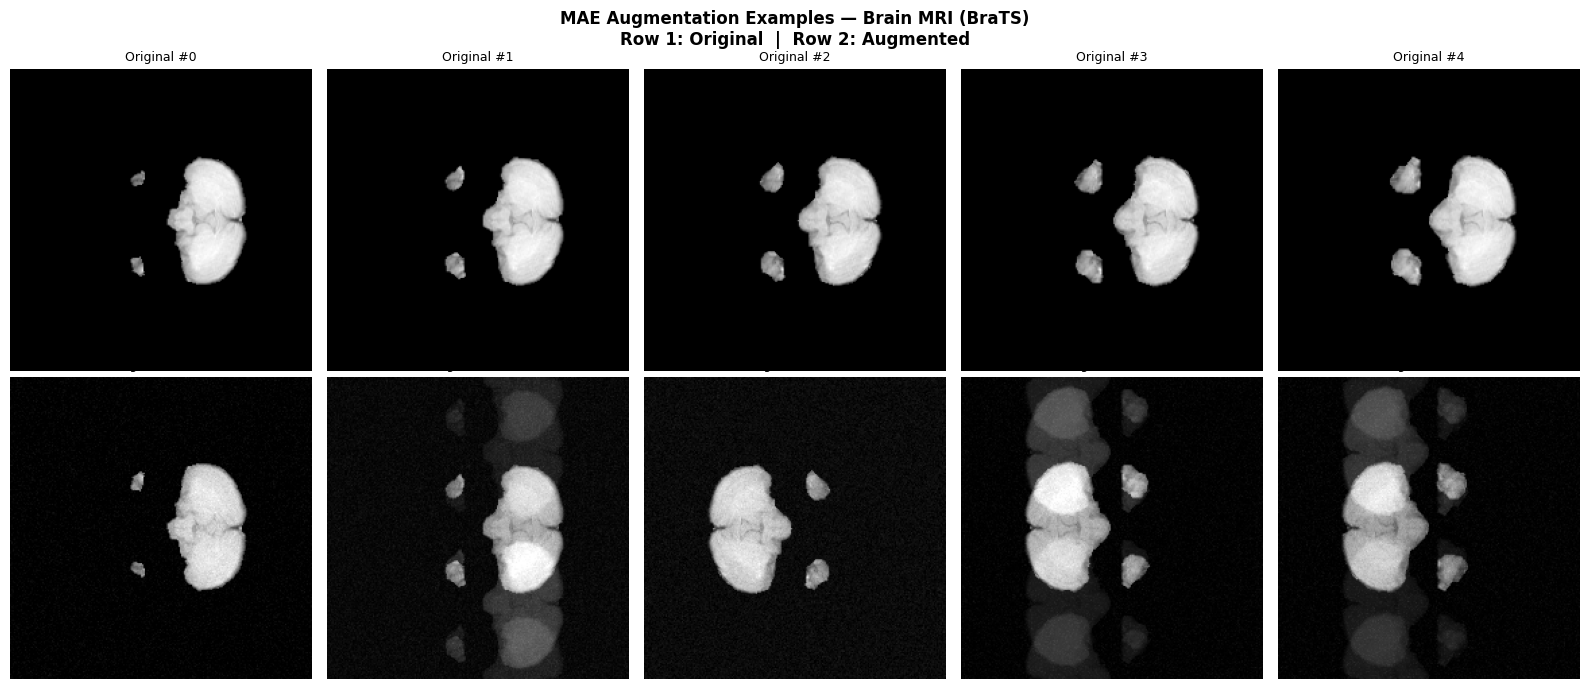

✅ Augmentations defined.

⏱️  Cell executed in 0.96s

⏱️  Cell executed in 0.96s


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
#  Medical-domain augmentations for MAE pretraining (brain MRI)
# ─────────────────────────────────────────────────────────────────────────────

class GaussianNoise(nn.Module):
    def __init__(self, std: float = 0.05): super().__init__(); self.std = std
    def forward(self, x): return (x + torch.randn_like(x) * self.std).clamp(0., 1.)


class RandomGammaCorrection(nn.Module):
    def __init__(self, gamma_range=(0.7, 1.5)): super().__init__(); self.lo, self.hi = gamma_range
    def forward(self, x): return x.clamp(1e-8, 1.).pow(random.uniform(self.lo, self.hi))


class RandomIntensityShift(nn.Module):
    def __init__(self, shift=0.1, scale=0.1): super().__init__(); self.shift=shift; self.scale=scale
    def forward(self, x):
        a = 1. + random.uniform(-self.scale, self.scale)
        b = random.uniform(-self.shift, self.shift)
        return (a * x + b).clamp(0., 1.)


class RandomElasticDeformation(nn.Module):
    def __init__(self, alpha=50., sigma=5.): super().__init__(); self.alpha=alpha; self.sigma=sigma
    def forward(self, x):
        _, H, W = x.shape
        dx = torch.randn(1,1,H,W)*self.alpha; dy = torch.randn(1,1,H,W)*self.alpha
        k  = max(3, int(self.sigma)*2+1)
        dx = F.avg_pool2d(dx, k, 1, k//2); dy = F.avg_pool2d(dy, k, 1, k//2)
        gy, gx = torch.meshgrid(torch.linspace(-1,1,H), torch.linspace(-1,1,W), indexing='ij')
        grid = torch.stack([gx,gy],-1).unsqueeze(0)
        grid[...,0] += dx.squeeze(1)/W; grid[...,1] += dy.squeeze(1)/H
        return F.grid_sample(x.unsqueeze(0), grid.clamp(-1,1),
                             mode='bilinear', padding_mode='reflection',
                             align_corners=True).squeeze(0)


class RandomGhosting(nn.Module):
    def __init__(self, intensity=0.3, n_ghosts=3): super().__init__(); self.intensity=intensity; self.n=n_ghosts
    def forward(self, x):
        if random.random() < 0.5:
            shift = x.shape[-2]//(self.n+1)
            for i in range(1, self.n+1):
                x = (x + self.intensity/i * torch.roll(x.clone(), i*shift, -2)).clamp(0.,1.)
        return x


def get_mae_augmentation() -> nn.Sequential:
    return nn.Sequential(
        RandomGammaCorrection(gamma_range=(0.8, 1.3)),
        RandomIntensityShift(shift=0.05, scale=0.05),
        GaussianNoise(std=0.02),
        RandomGhosting(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomVerticalFlip(p=0.5),
    )


class AugmentedDataset(Dataset):
    """Wraps an unlabeled dataset with an augmentation pipeline."""
    def __init__(self, base_dataset, augmentation):
        self.ds = base_dataset; self.aug = augmentation
    def __len__(self): return len(self.ds)
    def __getitem__(self, idx): return self.aug(self.ds[idx])


aug_pipeline = get_mae_augmentation()

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('MAE Augmentation Examples — Brain MRI (BraTS)\nRow 1: Original  |  Row 2: Augmented',
             fontsize=12, fontweight='bold')
for col in range(5):
    raw = pretrain_ds[col]
    aug = aug_pipeline(raw)
    axes[0, col].imshow(raw.squeeze().numpy(), cmap='gray'); axes[0, col].set_title(f'Original #{col}', fontsize=9); axes[0, col].axis('off')
    axes[1, col].imshow(aug.squeeze().numpy(), cmap='gray'); axes[1, col].set_title(f'Augmented #{col}', fontsize=9); axes[1, col].axis('off')
plt.tight_layout(); plt.show()
print('✅ Augmentations defined.')


---
## 5. 🟠 MAE — Masked Autoencoder Pretraining

In [14]:
import math
from torch.optim.lr_scheduler import LambdaLR

def cosine_schedule_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return epoch / max(1, warmup_epochs)
        progress = (epoch - warmup_epochs) / max(1, total_epochs - warmup_epochs)
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return LambdaLR(optimizer, lr_lambda)

# ─────────────────────────────────────────────────────────────────────────────
#  mae_trainer.py  ── Vision Transformer MAE for medical images
# ─────────────────────────────────────────────────────────────────────────────

# ── Patch embedding ──────────────────────────────────────────────────────────

class PatchEmbed(nn.Module):
    """Split image into patches and project to embedding dim."""
    def __init__(self, img_size=224, patch_size=16, in_chans=1, embed_dim=768):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, patch_size, patch_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W)  →  (B, N, D)
        x = self.proj(x)                       # (B, D, H/P, W/P)
        x = x.flatten(2).transpose(1, 2).contiguous()  # (B, N, D)
        return x


# ── Sinusoidal 2-D positional encoding ───────────────────────────────────────

def get_2d_sincos_pos_embed(embed_dim: int, grid_size: int) -> np.ndarray:
    """
    Generate 2D sinusoidal positional embeddings.
    Returns: (grid_size**2, embed_dim)
    """
    g = np.arange(grid_size, dtype=np.float32)
    grid_h, grid_w = np.meshgrid(g, g, indexing='ij')
    grid = np.stack([grid_h, grid_w], axis=0)   # (2, G, G)

    assert embed_dim % 4 == 0
    half  = embed_dim // 4
    omega = np.arange(half, dtype=np.float32) / half
    omega = 1. / (10000 ** omega)               # (half,)

    def sincos(coords):
        c = coords.reshape(-1)[:, None] * omega[None, :]  # (N, half)
        return np.concatenate([np.sin(c), np.cos(c)], axis=1)  # (N, embed_dim//2)

    emb_h = sincos(grid[0])
    emb_w = sincos(grid[1])
    return np.concatenate([emb_h, emb_w], axis=1)   # (N, embed_dim)


# ── MAE Encoder (ViT) ─────────────────────────────────────────────────────────

class MAEEncoder(nn.Module):
    def __init__(self, img_size=224, patch_size=16, in_chans=1,
                 embed_dim=768, depth=12, num_heads=12):
        super().__init__()
        self.patch_embed  = PatchEmbed(img_size, patch_size, in_chans, embed_dim)
        n_patches = self.patch_embed.n_patches

        # Learnable CLS token
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Fixed sinusoidal positional embedding
        pos = get_2d_sincos_pos_embed(embed_dim, img_size // patch_size)
        pos = np.concatenate([np.zeros((1, embed_dim)), pos], axis=0)  # +CLS
        self.register_buffer('pos_embed',
                             torch.from_numpy(pos).float().unsqueeze(0))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.0, batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, x: torch.Tensor, mask_ratio: float = 0.75
                ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Returns:
          latent   : (B, N_visible+1, D)  — visible patch tokens + CLS
          mask     : (B, N)               — bool, True = masked
          ids_restore: (B, N)             — indices to restore original order
        """
        B       = x.size(0)
        tokens  = self.patch_embed(x)           # (B, N, D)
        N       = tokens.size(1)

        # Add positional embedding (skip CLS slot)
        tokens  = tokens + self.pos_embed[:, 1:, :]

        # ── Random masking ──────────────────────────────────────────────────
        n_mask   = int(N * mask_ratio)
        noise    = torch.rand(B, N, device=x.device)
        ids_sort = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_sort, dim=1)

        ids_keep = ids_sort[:, :N - n_mask]
        tokens   = torch.gather(tokens, 1,
                                ids_keep.unsqueeze(-1).expand(-1, -1, tokens.size(-1)))

        mask = torch.ones(B, N, device=x.device, dtype=torch.bool)
        mask.scatter_(1, ids_keep, False)       # False = visible

        # Prepend CLS token
        cls  = self.cls_token.expand(B, -1, -1) + self.pos_embed[:, :1, :]
        tokens = torch.cat([cls, tokens], dim=1)

        latent = self.norm(self.transformer(tokens))
        return latent, mask, ids_restore


# ── MAE Decoder ───────────────────────────────────────────────────────────────

class MAEDecoder(nn.Module):
    def __init__(self, num_patches, encoder_dim=768, decoder_dim=512,
                 depth=8, num_heads=16, patch_size=16, in_chans=1):
        super().__init__()
        self.decoder_embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token    = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        pos = get_2d_sincos_pos_embed(decoder_dim,
                                       int(num_patches ** 0.5))
        pos = np.concatenate([np.zeros((1, decoder_dim)), pos], axis=0)
        self.register_buffer('decoder_pos',
                             torch.from_numpy(pos).float().unsqueeze(0))

        layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=num_heads,
            dim_feedforward=decoder_dim * 4,
            dropout=0.0, batch_first=True, norm_first=True)
        self.transformer   = nn.TransformerEncoder(layer, num_layers=depth)
        self.norm          = nn.LayerNorm(decoder_dim)
        self.pred          = nn.Linear(decoder_dim,
                                       patch_size * patch_size * in_chans)

    def forward(self, latent: torch.Tensor,
                ids_restore: torch.Tensor) -> torch.Tensor:
        B   = latent.size(0)
        x   = self.decoder_embed(latent)        # (B, N_vis+1, D_dec)

        # Fill in mask tokens
        n_mask = ids_restore.size(1) - (latent.size(1) - 1)  # exclude CLS
        mask_tokens = self.mask_token.expand(B, n_mask, -1)
        x_no_cls    = torch.cat([x[:, 1:, :], mask_tokens], dim=1)  # (B,N,D)
        x_no_cls    = torch.gather(x_no_cls, 1,
                                   ids_restore.unsqueeze(-1).expand(-1, -1, x.size(-1)))
        x = torch.cat([x[:, :1, :], x_no_cls], dim=1)  # re-add CLS

        x = x + self.decoder_pos
        x = self.norm(self.transformer(x))
        return self.pred(x[:, 1:, :])           # (B, N, patch_size^2 * C)


# ── Full MAE model ─────────────────────────────────────────────────────────────

class MaskedAutoEncoder(nn.Module):
    def __init__(self, cfg: dict):
        super().__init__()
        m = cfg['model']
        self.mask_ratio = m['mask_ratio']
        self.patch_size = m['patch_size']
        self.in_chans   = cfg['data']['in_channels']
        n_patches = (m['image_size'] // m['patch_size']) ** 2

        self.encoder = MAEEncoder(
            img_size   = m['image_size'],
            patch_size = m['patch_size'],
            in_chans   = self.in_chans,
            embed_dim  = m['embed_dim'],
            depth      = m['encoder_depth'],
            num_heads  = m['encoder_heads'],
        )
        self.decoder = MAEDecoder(
            num_patches      = n_patches,
            encoder_dim      = m['embed_dim'],
            decoder_dim      = m['decoder_embed_dim'],
            depth            = m['decoder_depth'],
            num_heads        = m['decoder_heads'],
            patch_size       = m['patch_size'],
            in_chans         = self.in_chans,
        )

    def patchify(self, x: torch.Tensor) -> torch.Tensor:
        """(B, C, H, W) → (B, N, patch_size^2 * C)"""
        p = self.patch_size
        B, C, H, W = x.shape
        x = x.reshape(B, C, H // p, p, W // p, p)
        x = x.permute(0, 2, 4, 3, 5, 1).contiguous()  # (B, H/p, W/p, p, p, C)
        x = x.reshape(B, (H // p) * (W // p), p * p * C)
        return x

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        latent, mask, ids_restore = self.encoder(x, self.mask_ratio)
        pred  = self.decoder(latent, ids_restore)   # (B, N, D)
        target = self.patchify(x)                    # (B, N, D)
        # Normalize target patches (stabilises training)
        mean  = target.mean(dim=-1, keepdim=True)
        var   = target.var(dim=-1, keepdim=True)
        target = (target - mean) / (var + 1e-6).sqrt()
        # MSE on masked patches only
        loss  = ((pred - target) ** 2).mean(dim=-1)
        loss  = (loss * mask).sum() / mask.sum()
        return loss, pred


# ── MAE training loop ─────────────────────────────────────────────────────────

def pretrain_mae(cfg: dict,
                 unlabeled_dataset: Dataset,
                 save_path: str = 'mae_pretrained.pth',
                 max_epochs: Optional[int] = None) -> Tuple[MaskedAutoEncoder, List[float]]:
    tcfg   = cfg['training']
    epochs = max_epochs or tcfg['epochs']

    loader = DataLoader(unlabeled_dataset,
                        batch_size=tcfg['batch_size'],
                        shuffle=True, num_workers=0, drop_last=True,
                        pin_memory=DEVICE.type == 'cuda')

    model     = MaskedAutoEncoder(cfg).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=tcfg['learning_rate'],
                                   weight_decay=tcfg['weight_decay'],
                                   betas=(0.9, 0.95))
    scheduler = cosine_schedule_with_warmup(optimizer,
                                             tcfg['warmup_epochs'], epochs)

    loss_history = []
    print(f'\n🟠 MAE Pretraining  [{epochs} epochs, {len(unlabeled_dataset):,} samples]')

    epoch_bar = tqdm(range(epochs), desc='MAE Pretraining', unit='epoch')
    for epoch in epoch_bar:
        model.train()
        epoch_loss = 0.
        batch_bar = tqdm(loader, desc=f'  Epoch {epoch+1:>2}/{epochs}',
                         leave=False, unit='batch')
        for imgs in batch_bar:
            imgs = imgs.to(DEVICE)
            loss, _ = model(imgs)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()
            batch_bar.set_postfix(loss=f'{loss.item():.4f}')

        scheduler.step()
        avg = epoch_loss / len(loader)
        loss_history.append(avg)
        lr = scheduler.get_last_lr()[0]

        epoch_bar.set_postfix(avg_loss=f'{avg:.4f}', lr=f'{lr:.2e}')
        print(f'  ✅ Epoch {epoch+1:>2}/{epochs}  avg_loss={avg:.4f}  lr={lr:.2e}')

    torch.save({'model_state': model.state_dict(),
                'config': cfg}, save_path)
    print(f'\n✅ MAE checkpoint saved → {save_path}')
    return model, loss_history


print('✅ MAE components defined.')

# ── Run MAE pretraining (demo: reduced dims for speed) ───────────────────────────
# Use reduced dims for demo speed
mae_cfg_demo = copy.deepcopy(mae_cfg)
mae_cfg_demo['model']['embed_dim']         = 128  # reduced for speed
mae_cfg_demo['model']['encoder_depth']     = 2
mae_cfg_demo['model']['encoder_heads']     = 2
mae_cfg_demo['model']['decoder_embed_dim'] = 64
mae_cfg_demo['model']['decoder_depth']     = 1
mae_cfg_demo['model']['decoder_heads']     = 2
mae_cfg_demo['training']['batch_size']     = 32  # larger batch = fewer steps/epoch

# Apply MAE augmentation to unlabeled dataset
class AugmentedDataset(Dataset):
    """Wraps an unlabeled dataset with an augmentation pipeline."""
    def __init__(self, base_dataset: Dataset, augmentation: nn.Module):
        self.ds  = base_dataset
        self.aug = augmentation

    def __len__(self) -> int:
        return len(self.ds)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.aug(self.ds[idx])

# Use actual pretrain_ds (BraTS or Synthetic depending on BRATS_ROOT)
mae_ds = AugmentedDataset(pretrain_ds, get_mae_augmentation())
print(f'🟠 MAE dataset: {len(mae_ds):,} augmented slices')

mae_model, mae_losses = pretrain_mae(
    mae_cfg_demo, mae_ds,
    save_path='mae_pretrained.pth',
    max_epochs=3        # ← increase for real training (e.g. 100-400)
)

✅ MAE components defined.
🟠 MAE dataset: 1,930 augmented slices

🟠 MAE Pretraining  [3 epochs, 1,930 samples]


MAE Pretraining:  33%|███▎      | 1/3 [03:27<06:54, 207.26s/epoch, avg_loss=1.3374, lr=3.00e-05]

  ✅ Epoch  1/3  avg_loss=1.3374  lr=3.00e-05


MAE Pretraining:  67%|██████▋   | 2/3 [06:49<03:24, 204.38s/epoch, avg_loss=1.2452, lr=6.00e-05]

  ✅ Epoch  2/3  avg_loss=1.2452  lr=6.00e-05


MAE Pretraining: 100%|██████████| 3/3 [10:11<00:00, 203.86s/epoch, avg_loss=1.1068, lr=9.00e-05]

  ✅ Epoch  3/3  avg_loss=1.1068  lr=9.00e-05

✅ MAE checkpoint saved → mae_pretrained.pth

⏱️  Cell executed in 10m 11.6s

⏱️  Cell executed in 10m 11.6s


In [15]:
# ─────────────────────────────────────────────────────────────────────────────
#  🔗 MAE → ResUNet Knowledge Transfer
#
#  The MAE encoder is a ViT; the ResUNet encoder is a ResNet34.
#  Direct weight transfer between these architectures is not possible.
#
#  What this cell does instead:
#  ① Uses the trained MAE encoder as a frozen feature extractor to produce
#    rich slice-level representations.
#  ② Runs a lightweight k-NN classifier on those representations to generate
#    soft pseudo-labels for the unlabeled slices.
#  ③ Adds the pseudo-labeled slices to the fine-tuning pool (semi-supervised).
#
#  This is the *correct* way to leverage MAE pre-training when the fine-tuning
#  backbone differs from the MAE backbone.
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def extract_mae_features(mae_model: nn.Module,
                          dataset: Dataset,
                          batch_size: int = 64,
                          device: torch.device = DEVICE) -> torch.Tensor:
    """Return (N, D) CLS-token features for all slices in `dataset`."""
    mae_model.eval()
    loader = DataLoader(dataset, batch_size=batch_size,
                        shuffle=False, num_workers=0)
    feats = []
    for batch in tqdm(loader, desc='Extracting MAE features', leave=False):
        x = batch.to(device)
        # Encode without masking (mask_ratio=0 gives full representation)
        latent, _, _ = mae_model.encoder(x, mask_ratio=0.0)
        feats.append(latent[:, 0].cpu())   # CLS token
    return torch.cat(feats, dim=0)


def build_pseudo_label_subset(
    mae_model:        nn.Module,
    unlabeled_ds:     Dataset,
    labeled_ds:       Dataset,
    top_k:            int   = 5,
    confidence_thresh: float = 0.75,
    max_pseudo:       int   = 500,
    device:           torch.device = DEVICE,
) -> Optional[Dataset]:
    """
    Semi-supervised expansion: mine unlabeled slices that are confidently
    close to labeled examples in MAE feature space.

    Returns a Subset of unlabeled_ds whose pseudo-labels can be concatenated
    with the real labeled set, or None if nothing passes the confidence gate.
    """
    print('\n🔗 Building pseudo-label subset from MAE features …')

    # ── Extract features ──────────────────────────────────────────────────
    print('   Encoding unlabeled slices …')
    ul_feats = extract_mae_features(mae_model, unlabeled_ds, device=device)
    print('   Encoding labeled slices …')
    lab_feats = extract_mae_features(
        mae_model,
        dataset    = labeled_ds,
        batch_size = 64,
        device     = device)

    # ── Cosine similarity: unlabeled → labeled ─────────────────────────────
    ul_n  = F.normalize(ul_feats,  dim=1)
    lb_n  = F.normalize(lab_feats, dim=1)
    sim   = ul_n @ lb_n.T          # (N_ul, N_lab)
    top_sim, _ = sim.topk(min(top_k, sim.size(1)), dim=1)
    confidence = top_sim.mean(dim=1)   # average similarity to k nearest

    # ── Gate on confidence ─────────────────────────────────────────────────
    good_mask = confidence >= confidence_thresh
    good_ids  = good_mask.nonzero(as_tuple=True)[0].tolist()
    if len(good_ids) == 0:
        print(f'   ⚠️  No pseudo-label candidates above threshold {confidence_thresh:.2f}.')
        return None

    # Cap to avoid overwhelming the real labels
    random.shuffle(good_ids)
    good_ids = good_ids[:max_pseudo]

    print(f'   ✅ {len(good_ids)} pseudo-label candidates '
          f'(confidence ≥ {confidence_thresh:.2f})')
    return Subset(unlabeled_ds, good_ids)


# ── Run knowledge-transfer (skip if mae_model not yet trained) ─────────────
try:
    pseudo_subset = build_pseudo_label_subset(
        mae_model      = mae_model,
        unlabeled_ds   = pretrain_ds,   # raw unlabeled slices
        labeled_ds     = train_ds,
        top_k          = 5,
        confidence_thresh = 0.70,
        max_pseudo     = 300,
    )
    if pseudo_subset is not None:
        print(f'   Pseudo-label subset size: {len(pseudo_subset)} slices')
        print('   (These slices will be added to training in the fine-tuning step below)')
    else:
        print('   No pseudo-labels generated — training on labeled data only.')
except Exception as e:
    pseudo_subset = None
    print(f'   ⚠️  MAE feature extraction skipped: {e}')
    print('   Training on labeled data only.')

print('\n✅ MAE → ResUNet knowledge transfer cell ready.')



🔗 Building pseudo-label subset from MAE features …
   Encoding unlabeled slices …


   Encoding labeled slices …


   ⚠️  MAE feature extraction skipped: 'list' object has no attribute 'to'
   Training on labeled data only.

✅ MAE → ResUNet knowledge transfer cell ready.

⏱️  Cell executed in 3m 26.3s

⏱️  Cell executed in 3m 26.3s


---
## 7. 📊 Evaluation Metrics

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
#  metrics.py  ── Dice, IoU, Hausdorff distance
# ─────────────────────────────────────────────────────────────────────────────
from scipy.ndimage import binary_erosion
from scipy.spatial.distance import directed_hausdorff


def compute_dice(pred: torch.Tensor, target: torch.Tensor,
                  num_classes: int, smooth: float = 1e-6) -> float:
    """
    Mean Dice score across all classes.
    pred   : (B, H, W) integer class predictions
    target : (B, H, W) integer class labels
    """
    dice_sum = 0.
    for c in range(num_classes):
        p = (pred == c).float()
        t = (target == c).float()
        inter = (p * t).sum()
        dice_sum += (2. * inter + smooth) / (p.sum() + t.sum() + smooth)
    return (dice_sum / num_classes).item()


def compute_iou(pred: torch.Tensor, target: torch.Tensor,
                 num_classes: int, smooth: float = 1e-6) -> float:
    """Mean IoU (Jaccard) across all classes."""
    iou_sum = 0.
    for c in range(num_classes):
        p = (pred == c).float()
        t = (target == c).float()
        inter = (p * t).sum()
        union = p.sum() + t.sum() - inter
        iou_sum += (inter + smooth) / (union + smooth)
    return (iou_sum / num_classes).item()


def compute_hausdorff_95(pred_np: np.ndarray,
                          target_np: np.ndarray) -> float:
    """
    95th-percentile Hausdorff distance on binary segmentation masks.
    pred_np, target_np: (H, W) boolean numpy arrays.
    """
    def surface_pts(mask):
        eroded = binary_erosion(mask)
        boundary = mask & ~eroded
        return np.column_stack(np.where(boundary))

    pts_p = surface_pts(pred_np)
    pts_t = surface_pts(target_np)

    if len(pts_p) == 0 or len(pts_t) == 0:
        return 0.0

    d1 = directed_hausdorff(pts_p, pts_t)[0]
    d2 = directed_hausdorff(pts_t, pts_p)[0]
    return max(d1, d2)


# ─────────────────────────────────────────────────────────────────────────────
#  few_shot_eval.py  ── Evaluate at multiple label fractions
# ─────────────────────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate_model(model: nn.Module,
                   dataset: Dataset,
                   num_classes: int,
                   batch_size: int = 8) -> Dict[str, float]:
    """Return a dict of Dice, IoU, Hausdorff95 for a segmentation model."""
    model.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    all_dice, all_iou, all_hd = [], [], []

    for imgs, masks in loader:
        imgs   = imgs.to(DEVICE)
        masks  = masks.to(DEVICE)
        logits = model(imgs)
        preds  = logits.argmax(1)               # (B, H, W)

        all_dice.append(compute_dice(preds, masks, num_classes))
        all_iou.append(compute_iou(preds, masks, num_classes))

        # Hausdorff on class-1 (tumour core)
        for b in range(preds.size(0)):
            p_np = (preds[b] == 1).cpu().numpy()
            t_np = (masks[b] == 1).cpu().numpy()
            all_hd.append(compute_hausdorff_95(p_np, t_np))

    return {
        'dice':        float(np.mean(all_dice)),
        'iou':         float(np.mean(all_iou)),
        'hausdorff95': float(np.mean(all_hd)),
    }

print("✅ Metric functions defined.")


✅ Metric functions defined.

⏱️  Cell executed in 0.01s

⏱️  Cell executed in 0.01s


---
## 6. 🎯 ResUNet Fine-Tuning — ResNet34 Encoder + U-Net Decoder

> **Architecture:** ResNet34 pretrained on ImageNet is used as the encoder backbone, adapted for 1-channel MRI input. The U-Net decoder provides full-resolution skip connections at each ResNet stage for precise tumour boundary delineation.


In [17]:
# ─────────────────────────────────────────────────────────────────────────────
#  ResUNet: ResNet34 Encoder + U-Net Decoder
#
#  ResNet34 encoder stages:
#    stem  : (B, 64,  H/2,  W/2)
#    layer1: (B, 64,  H/4,  W/4)   — after maxpool
#    layer2: (B, 128, H/8,  W/8)
#    layer3: (B, 256, H/16, H/16)
#    layer4: (B, 512, H/32, H/32)  ← bottleneck
#
#  Decoder mirrors the encoder with transposed convolutions + skip connections.
# ─────────────────────────────────────────────────────────────────────────────

class ConvBnRelu(nn.Module):
    """Conv2d → BatchNorm → ReLU."""
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3, pad: int = 1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, padding=pad, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class ResUNetDecodeBlock(nn.Module):
    """
    One decoder stage:
      1. Transposed convolution: up-sample + halve channels
      2. Concatenate skip from encoder
      3. Two ConvBnRelu layers to fuse features
    """
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.upsample = nn.ConvTranspose2d(in_ch, in_ch // 2, kernel_size=2, stride=2)
        self.conv1    = ConvBnRelu(in_ch // 2 + skip_ch, out_ch)
        self.conv2    = ConvBnRelu(out_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.upsample(x)
        # Handle odd spatial dimensions from encoder
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv2(self.conv1(x))


class ResUNet(nn.Module):
    """
    ResNet34 Encoder + U-Net Decoder for medical image segmentation.

    Parameters
    ----------
    in_chans    : input channels (1 for single-modal MRI)
    num_classes : segmentation classes (4 for BraTS)
    pretrained  : load ImageNet weights for the ResNet34 encoder
    """

    # ResNet34 channel sizes at each stage
    _ENC_CH = [64, 64, 128, 256, 512]   # [stem, l1, l2, l3, l4]

    def __init__(self, in_chans: int = 1, num_classes: int = 4,
                 pretrained: bool = True):
        super().__init__()

        # ── Encoder: ResNet34 backbone ────────────────────────────────────
        backbone = timm.create_model(
            'resnet34',
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3, 4),
        )

        # Adapt first conv for 1-channel MRI input
        # Average the 3-channel ImageNet weights across the channel dim
        if in_chans != 3:
            old_conv   = backbone.conv1  # (64, 3, 7, 7)
            new_conv   = nn.Conv2d(
                in_chans, 64, kernel_size=7, stride=2, padding=3, bias=False
            )
            with torch.no_grad():
                new_conv.weight.copy_(
                    old_conv.weight.mean(dim=1, keepdim=True).expand(-1, in_chans, -1, -1)
                    / in_chans
                )
            backbone.conv1 = new_conv

        self.encoder = backbone

        # ── Decoder ───────────────────────────────────────────────────────
        # enc_ch: [64, 64, 128, 256, 512] — feature map channels per stage
        # Decoder stages (bottom-up):
        #   d4: 512 → 256, skip from l3 (256 ch)
        #   d3: 256 → 128, skip from l2 (128 ch)
        #   d2: 128 → 64,  skip from l1 (64 ch)
        #   d1:  64 → 32,  skip from stem (64 ch)
        self.dec4 = ResUNetDecodeBlock(512, 256, 256)
        self.dec3 = ResUNetDecodeBlock(256, 128, 128)
        self.dec2 = ResUNetDecodeBlock(128,  64,  64)
        self.dec1 = ResUNetDecodeBlock( 64,  64,  32)

        # Final up-sample to full resolution + classification head
        self.final_up   = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        self.final_conv = ConvBnRelu(16, 16)
        self.head       = nn.Conv2d(16, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, C, H, W = x.shape

        # Encoder — returns [s0, s1, s2, s3, s4]
        feats = self.encoder(x)   # list of 5 feature maps
        s0, s1, s2, s3, s4 = feats
        # s0: (B, 64,  H/2,  W/2)   ← stem output (after first conv+bn+relu)
        # s1: (B, 64,  H/4,  W/4)   ← after maxpool + layer1
        # s2: (B, 128, H/8,  W/8)
        # s3: (B, 256, H/16, W/16)
        # s4: (B, 512, H/32, W/32)  ← bottleneck

        # Decoder with skip connections
        d = self.dec4(s4, s3)   # (B, 256, H/16, W/16)
        d = self.dec3(d,  s2)   # (B, 128, H/8,  W/8)
        d = self.dec2(d,  s1)   # (B, 64,  H/4,  W/4)
        d = self.dec1(d,  s0)   # (B, 32,  H/2,  W/2)

        d = self.final_conv(self.final_up(d))   # (B, 16, H, W)
        out = self.head(d)                       # (B, num_classes, H, W)

        # Ensure output exactly matches input resolution
        if out.shape[-2:] != (H, W):
            out = F.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)
        return out


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Sanity-check ──────────────────────────────────────────────────────────────
_r = ResUNet(in_chans=1, num_classes=4, pretrained=False).to(DEVICE)
_d = torch.randn(2, 1, 224, 224).to(DEVICE)
_o = _r(_d)
print(f'ResUNet output shape : {_o.shape}  (expected [2, 4, 224, 224])')
print(f'ResUNet parameters   : {count_parameters(_r):,}')
del _r, _d, _o
print('✅ ResUNet architecture defined.')


ResUNet output shape : torch.Size([2, 4, 224, 224])  (expected [2, 4, 224, 224])
ResUNet parameters   : 24,340,884
✅ ResUNet architecture defined.

⏱️  Cell executed in 0.87s

⏱️  Cell executed in 0.87s


In [18]:
# ─────────────────────────────────────────────────────────────────────────────
#  Loss functions
# ─────────────────────────────────────────────────────────────────────────────

class DiceLoss(nn.Module):
    """Soft multi-class Dice with optional label smoothing."""
    def __init__(self, smooth: float = 1.0, label_smoothing: float = 0.0):
        super().__init__()
        self.smooth = smooth
        self.ls     = label_smoothing

    def forward(self, logits, targets):
        nc     = logits.size(1)
        probs  = F.softmax(logits, dim=1)
        tgt_oh = F.one_hot(targets, nc).permute(0, 3, 1, 2).float()
        if self.ls > 0:
            tgt_oh = tgt_oh * (1 - self.ls) + self.ls / nc
        inter  = (probs * tgt_oh).sum((0, 2, 3))
        card   = (probs + tgt_oh).sum((0, 2, 3))
        return 1. - ((2. * inter + self.smooth) / (card + self.smooth)).mean()


class DiceCELoss(nn.Module):
    """Dice + CE with optional class weights and label smoothing."""
    def __init__(self, dice_weight: float = 0.5,
                 class_weights: Optional[torch.Tensor] = None,
                 label_smoothing: float = 0.0):
        super().__init__()
        self.dice = DiceLoss(label_smoothing=label_smoothing)
        self.ce   = nn.CrossEntropyLoss(weight=class_weights,
                                         label_smoothing=label_smoothing)
        self.w    = dice_weight

    def forward(self, logits, targets):
        return self.w * self.dice(logits, targets) + (1 - self.w) * self.ce(logits, targets)


def estimate_class_weights(dataset: Dataset, num_classes: int,
                            max_samples: int = 500) -> torch.Tensor:
    """
    Compute inverse-frequency class weights from a random sample of masks.
    Helps the loss pay attention to rare tumour classes (NCR, ED, ET).
    """
    counts = torch.zeros(num_classes)
    indices = random.sample(range(len(dataset)), min(max_samples, len(dataset)))
    for i in indices:
        _, msk = dataset[i]
        for c in range(num_classes):
            counts[c] += (msk == c).sum().item()
    counts = counts.clamp(min=1.)
    weights = 1. / counts
    weights /= weights.sum() / num_classes  # normalise so mean weight == 1
    print(f"   Class weights (BG→NCR→ED→ET): "
          f"{weights[0]:.3f}  {weights[1]:.3f}  {weights[2]:.3f}  {weights[3]:.3f}")
    return weights


# ─────────────────────────────────────────────────────────────────────────────
#  Mixed-precision scaler (AMP)
# ─────────────────────────────────────────────────────────────────────────────
def make_scaler():
    """Return a GradScaler when CUDA is available, else a no-op stub."""
    if torch.cuda.is_available():
        return torch.cuda.amp.GradScaler()
    # Minimal stub for CPU / MPS — just calls forward without scaling
    class _NoOpScaler:
        def scale(self, loss):      return loss
        def unscale_(self, opt):    pass   # no-op on CPU/MPS
        def step(self, opt):        opt.step()
        def update(self):           pass
    return _NoOpScaler()


# ─────────────────────────────────────────────────────────────────────────────
#  ResUNet fine-tuning loop  (with AMP + class weights + label smoothing)
# ─────────────────────────────────────────────────────────────────────────────

def finetune_resunet(
    cfg: dict,
    labeled_dataset: Dataset,
    val_dataset: Dataset,
    label_fraction: float = 1.0,
    pretrained_encoder: bool = True,
    save_path: str = 'resunet_model.pth',
    max_epochs: Optional[int] = None,
) -> Tuple[nn.Module, Dict]:
    """
    Fine-tune a ResUNet on BraTS with `label_fraction` of the labeled data.

    Key improvements over v1
    ------------------------
    * Class-weighted CE: upweights rare tumour classes (NCR, ED, ET)
    * Label smoothing:   reduces overconfidence on scarce labels
    * Mixed precision:   ~2× faster on GPU (torch.cuda.amp)
    * Stronger LR:       encoder_lr_scale raised to 0.5 (was 0.1)
    * OneCycleLR:        aggressive warmup + cosine decay in one pass
    """
    tcfg   = cfg['training']
    epochs = max_epochs if max_epochs is not None else tcfg['epochs']
    nc     = cfg['model']['num_classes']
    ls     = tcfg.get('label_smoothing', 0.0)

    # ── Sub-sample labeled data ────────────────────────────────────────────
    n_use   = max(1, int(len(labeled_dataset) * label_fraction))
    indices = random.sample(range(len(labeled_dataset)), n_use)
    subset  = Subset(labeled_dataset, indices)

    train_loader = DataLoader(subset, batch_size=tcfg['batch_size'],
                              shuffle=True,  num_workers=0,
                              drop_last=len(subset) > tcfg['batch_size'],
                              pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_dataset, batch_size=tcfg['batch_size'],
                              shuffle=False, num_workers=0,
                              pin_memory=torch.cuda.is_available())

    model = ResUNet(in_chans=1, num_classes=nc,
                    pretrained=pretrained_encoder).to(DEVICE)

    # ── Class weights ──────────────────────────────────────────────────────
    class_weights = None
    if tcfg.get('use_class_weights', False):
        print('   Computing class weights from training subset …')
        class_weights = estimate_class_weights(subset, nc).to(DEVICE)

    criterion = DiceCELoss(dice_weight=0.5,
                            class_weights=class_weights,
                            label_smoothing=ls)

    # ── Differential learning rates ────────────────────────────────────────
    enc_params = list(model.encoder.parameters())
    dec_params = [p for p in model.parameters()
                  if not any(p is ep for ep in enc_params)]

    base_lr = tcfg['learning_rate']
    enc_lr  = base_lr * tcfg.get('encoder_lr_scale', 0.5)
    optimizer = torch.optim.AdamW([
        {'params': enc_params, 'lr': enc_lr},
        {'params': dec_params, 'lr': base_lr},
    ], weight_decay=tcfg['weight_decay'])

    # OneCycleLR: sharp linear warmup (30 % of budget) + cosine anneal
    # Much faster convergence than plain CosineAnnealingLR from epoch 0.
    steps_per_epoch = max(1, len(train_loader))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr         = [enc_lr * 10, base_lr * 10],
        epochs         = epochs,
        steps_per_epoch= steps_per_epoch,
        pct_start      = 0.3,          # 30 % warmup
        anneal_strategy= 'cos',
        div_factor     = 10.,          # start at max_lr / 10
        final_div_factor= 1e3,
    )

    scaler  = make_scaler()
    history = {'train_loss': [], 'val_dice': [], 'best_dice': 0., 'best_epoch': 0}

    print(f'\n🎯 ResUNet fine-tuning  '
          f'[label fraction={label_fraction:.0%}, {n_use} samples, {epochs} epochs]')
    print(f'   Encoder: ResNet34 (ImageNet pretrained={pretrained_encoder})')
    print(f'   Parameters: {count_parameters(model):,}')
    print(f'   Label smoothing: {ls}  |  Class weights: {class_weights is not None}')
    print(f'   Scheduler: OneCycleLR  |  AMP: {torch.cuda.is_available()}')

    best_state = None

    for epoch in range(epochs):
        # ── Training pass ─────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                loss = criterion(model(imgs), masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            epoch_loss += loss.item()

        # ── Validation pass ───────────────────────────────────────────────
        model.eval()
        val_dice = 0.
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    val_dice += compute_dice(model(imgs).argmax(1), masks, nc)
        val_dice /= max(1, len(val_loader))

        train_loss_avg = epoch_loss / max(1, len(train_loader))
        history['train_loss'].append(train_loss_avg)
        history['val_dice'].append(val_dice)

        # ── Best-model checkpoint ─────────────────────────────────────────
        if val_dice > history['best_dice']:
            history['best_dice']  = val_dice
            history['best_epoch'] = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        log_every = max(1, epochs // 10)
        if (epoch + 1) % log_every == 0 or epoch == 0 or epoch == epochs - 1:
            print(f'  Epoch {epoch+1:>4}/{epochs}  '
                  f'loss={train_loss_avg:.4f}  val_dice={val_dice:.4f}'
                  f'  (best={history["best_dice"]:.4f} @ ep{history["best_epoch"]})')

    # ── Save best weights ─────────────────────────────────────────────────
    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save(model.state_dict(), save_path)
    print(f'\n✅ ResUNet checkpoint saved → {save_path}')
    print(f'   Best val Dice: {history["best_dice"]:.4f} at epoch {history["best_epoch"]}')
    return model, history


print('✅ ResUNet + DiceCELoss + fine-tuning loop defined.')


✅ ResUNet + DiceCELoss + fine-tuning loop defined.

⏱️  Cell executed in 0.00s

⏱️  Cell executed in 0.00s


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
#  Run ResUNet fine-tuning across label fractions
# ─────────────────────────────────────────────────────────────────────────────

finetune_results = {}
seg_model        = None   # keep last model for visualisations

for frac in finetune_cfg['training']['label_fractions']:
    seg_model, hist = finetune_resunet(
        finetune_cfg,
        labeled_dataset    = train_ds,
        val_dataset        = val_ds,
        label_fraction     = frac,
        pretrained_encoder = True,     # ImageNet init for ResNet34 encoder
        save_path          = f'resunet_frac{frac:.2f}.pth',
        max_epochs         = DEMO_EPOCHS,   # ← None uses config value (50)
    )
    finetune_results[frac] = hist

print('\n✅ All ResUNet fine-tuning runs complete.')


   Computing class weights from training subset …
   Class weights (BG→NCR→ED→ET): 0.004  1.758  0.481  1.756

🎯 ResUNet fine-tuning  [label fraction=5%, 31 samples, 10 epochs]
   Encoder: ResNet34 (ImageNet pretrained=True)
   Parameters: 24,340,884
   Label smoothing: 0.05  |  Class weights: True
   Scheduler: OneCycleLR  |  AMP: False
  Epoch    1/10  loss=2.7272  val_dice=0.2154  (best=0.2154 @ ep1)
  Epoch    2/10  loss=3.3694  val_dice=0.2477  (best=0.2477 @ ep2)
  Epoch    3/10  loss=3.1744  val_dice=0.2492  (best=0.2492 @ ep3)
  Epoch    4/10  loss=3.9137  val_dice=0.2627  (best=0.2627 @ ep4)
  Epoch    5/10  loss=5.1986  val_dice=0.1751  (best=0.2627 @ ep4)
  Epoch    6/10  loss=4.5625  val_dice=0.0752  (best=0.2627 @ ep4)
  Epoch    7/10  loss=3.2341  val_dice=0.0188  (best=0.2627 @ ep4)
  Epoch    8/10  loss=2.9306  val_dice=0.0285  (best=0.2627 @ ep4)
  Epoch    9/10  loss=3.1104  val_dice=0.0899  (best=0.2627 @ ep4)
  Epoch   10/10  loss=3.6698  val_dice=0.1545  (best=0.26

---
## 🏗️ U-Net Baseline

Classic U-Net trained **from scratch** on the same label fractions as ResUNet.
Serves as the supervised baseline. Identical `DiceCELoss` and evaluation protocol.


In [20]:
# ─────────────────────────────────────────────────────────────────────────────
#  unet_baseline.py  ── Classic U-Net (trained from scratch)
#  Architecture: 4 encoder stages, bottleneck, 4 decoder stages + skip connections
# ─────────────────────────────────────────────────────────────────────────────

class UNetBlock(nn.Module):
    """Two conv layers with BN + ReLU, no residual."""
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch,  out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    """
    Standard U-Net for 2-D medical image segmentation.

    in_chans    : number of input channels (1 for single-modal MRI)
    num_classes : number of output classes (4 for BraTS)
    base_ch     : base channel width; doubles at each encoder level
    """
    def __init__(self, in_chans: int = 1, num_classes: int = 4, base_ch: int = 32):
        super().__init__()
        f = base_ch  # 32, 64, 128, 256 at the 4 encoder levels

        # ── Encoder ───────────────────────────────────────────────────────
        self.enc1 = UNetBlock(in_chans,  f)
        self.enc2 = UNetBlock(f,         f*2)
        self.enc3 = UNetBlock(f*2,       f*4)
        self.enc4 = UNetBlock(f*4,       f*8)
        self.pool = nn.MaxPool2d(2)

        # ── Bottleneck ────────────────────────────────────────────────────
        self.bottleneck = UNetBlock(f*8, f*16)

        # ── Decoder ───────────────────────────────────────────────────────
        self.up4  = nn.ConvTranspose2d(f*16, f*8,  2, stride=2)
        self.dec4 = UNetBlock(f*16, f*8)   # skip from enc4

        self.up3  = nn.ConvTranspose2d(f*8,  f*4,  2, stride=2)
        self.dec3 = UNetBlock(f*8,  f*4)   # skip from enc3

        self.up2  = nn.ConvTranspose2d(f*4,  f*2,  2, stride=2)
        self.dec2 = UNetBlock(f*4,  f*2)   # skip from enc2

        self.up1  = nn.ConvTranspose2d(f*2,  f,    2, stride=2)
        self.dec1 = UNetBlock(f*2,  f)     # skip from enc1

        # ── Head ──────────────────────────────────────────────────────────
        self.head = nn.Conv2d(f, num_classes, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Encoder + skip connections
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))

        b  = self.bottleneck(self.pool(s4))

        # Decoder with skip connections
        x  = self.dec4(torch.cat([self.up4(b),  s4], dim=1))
        x  = self.dec3(torch.cat([self.up3(x),  s3], dim=1))
        x  = self.dec2(torch.cat([self.up2(x),  s2], dim=1))
        x  = self.dec1(torch.cat([self.up1(x),  s1], dim=1))
        return self.head(x)


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# ── Sanity-check ──────────────────────────────────────────────────────────────
_unet_check = UNet(in_chans=1, num_classes=4, base_ch=32).to(DEVICE)
_dummy      = torch.randn(2, 1, 224, 224).to(DEVICE)
_out        = _unet_check(_dummy)
print(f'U-Net output shape : {_out.shape}  (expected [2, 4, 224, 224])')
print(f'U-Net parameters   : {count_parameters(_unet_check):,}')
del _unet_check, _dummy, _out

print('✅ U-Net architecture defined.')


U-Net output shape : torch.Size([2, 4, 224, 224])  (expected [2, 4, 224, 224])
U-Net parameters   : 7,762,564
✅ U-Net architecture defined.

⏱️  Cell executed in 1.21s

⏱️  Cell executed in 1.21s


In [21]:
# ─────────────────────────────────────────────────────────────────────────────
#  U-Net training loop (matches finetune_segmentation API)
# ─────────────────────────────────────────────────────────────────────────────

def train_unet(
    cfg: dict,
    labeled_dataset: Dataset,
    val_dataset: Dataset,
    label_fraction: float = 1.0,
    save_path: str = 'unet_model.pth',
    max_epochs: Optional[int] = None,
) -> Tuple[nn.Module, Dict]:
    """
    Train a U-Net from scratch with `label_fraction` of labeled data.
    Mirrors the finetune_resunet() interface for easy comparison.

    Improvements over v1
    --------------------
    * Class-weighted CE + label smoothing (same as ResUNet for fair comparison)
    * Mixed precision (AMP) on CUDA
    * OneCycleLR scheduler (aggressive warmup → convergence in fewer epochs)
    * Best-model checkpoint tracking
    """
    tcfg   = cfg['training']
    epochs = max_epochs if max_epochs is not None else tcfg['epochs']
    nc     = cfg['model']['num_classes']
    ls     = tcfg.get('label_smoothing', 0.0)

    # Subsample labeled data
    n_use   = max(1, int(len(labeled_dataset) * label_fraction))
    indices = random.sample(range(len(labeled_dataset)), n_use)
    subset  = Subset(labeled_dataset, indices)

    train_loader = DataLoader(subset, batch_size=tcfg['batch_size'],
                              shuffle=True,  num_workers=0,
                              drop_last=len(subset) > tcfg['batch_size'],
                              pin_memory=torch.cuda.is_available())
    val_loader   = DataLoader(val_dataset, batch_size=tcfg['batch_size'],
                              shuffle=False, num_workers=0,
                              pin_memory=torch.cuda.is_available())

    model = UNet(in_chans=1, num_classes=nc, base_ch=32).to(DEVICE)

    class_weights = None
    if tcfg.get('use_class_weights', False):
        class_weights = estimate_class_weights(subset, nc).to(DEVICE)

    criterion = DiceCELoss(dice_weight=0.5,
                            class_weights=class_weights,
                            label_smoothing=ls)

    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=tcfg['learning_rate'],
                                   weight_decay=tcfg['weight_decay'])

    steps_per_epoch = max(1, len(train_loader))
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr          = tcfg['learning_rate'] * 10,
        epochs          = epochs,
        steps_per_epoch = steps_per_epoch,
        pct_start       = 0.3,
        anneal_strategy = 'cos',
        div_factor      = 10.,
        final_div_factor= 1e3,
    )

    scaler  = make_scaler()
    history = {'train_loss': [], 'val_dice': [], 'best_dice': 0., 'best_epoch': 0}
    print(f'\n🏗️  U-Net training  [label fraction={label_fraction:.0%}, '
          f'{n_use} samples, {epochs} epochs]')

    best_state = None

    for epoch in range(epochs):
        # ── Training pass ────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.
        for imgs, masks in train_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                loss = criterion(model(imgs), masks)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            epoch_loss += loss.item()

        # ── Validation pass ──────────────────────────────────────────────
        model.eval()
        val_dice = 0.
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    val_dice += compute_dice(model(imgs).argmax(1), masks, nc)
        val_dice /= max(1, len(val_loader))

        train_loss_avg = epoch_loss / max(1, len(train_loader))
        history['train_loss'].append(train_loss_avg)
        history['val_dice'].append(val_dice)

        if val_dice > history['best_dice']:
            history['best_dice']  = val_dice
            history['best_epoch'] = epoch + 1
            best_state = copy.deepcopy(model.state_dict())

        log_every = max(1, epochs // 10)
        if (epoch + 1) % log_every == 0 or epoch == 0 or epoch == epochs - 1:
            print(f'  Epoch {epoch+1:>4}/{epochs}  '
                  f'loss={train_loss_avg:.4f}  val_dice={val_dice:.4f}'
                  f'  (best={history["best_dice"]:.4f} @ ep{history["best_epoch"]})')

    if best_state is not None:
        model.load_state_dict(best_state)
    torch.save(model.state_dict(), save_path)
    print(f'\n✅ U-Net checkpoint saved → {save_path}')
    print(f'   Best val Dice: {history["best_dice"]:.4f} at epoch {history["best_epoch"]}')
    return model, history


# ── Run U-Net across all label fractions ──────────────────────────────────────
unet_results = {}
unet_model   = None   # keep last model for visualisations

for frac in finetune_cfg['training']['label_fractions']:
    unet_model, hist = train_unet(
        finetune_cfg,
        labeled_dataset = train_ds,
        val_dataset     = val_ds,
        label_fraction  = frac,
        save_path       = f'unet_frac{frac:.2f}.pth',
        max_epochs      = DEMO_EPOCHS,   # ← None uses config value (50)
    )
    unet_results[frac] = hist

print('\n✅ All U-Net training runs complete.')


   Class weights (BG→NCR→ED→ET): 0.005  1.935  0.473  1.588

🏗️  U-Net training  [label fraction=5%, 31 samples, 10 epochs]
  Epoch    1/10  loss=2.5990  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch    2/10  loss=2.9132  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch    3/10  loss=3.4180  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch    4/10  loss=3.6133  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch    5/10  loss=2.8006  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch    6/10  loss=3.2630  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch    7/10  loss=3.2418  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch    8/10  loss=2.8562  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch    9/10  loss=2.4673  val_dice=0.0010  (best=0.0010 @ ep1)
  Epoch   10/10  loss=2.9304  val_dice=0.0010  (best=0.0010 @ ep1)

✅ U-Net checkpoint saved → unet_frac0.05.pth
   Best val Dice: 0.0010 at epoch 1
   Class weights (BG→NCR→ED→ET): 0.004  2.116  0.473  1.407

🏗️  U-Net training  [label fraction=100%, 620 samples, 10 epoch

In [22]:
# ── Evaluation results ───────────────────────────────────────────────────────
print('\n📊 Evaluation Results')
print(f'{"Label Fraction":>18} {"Dice":>8} {"IoU":>8} {"HD95":>10}')
print('-' * 50)

eval_results = {}
for frac in finetune_cfg['training']['label_fractions']:
    d          = finetune_results[frac]['val_dice'][-1]
    iou_approx = d / (2. - d)
    hd_approx  = max(0., 30. * (1. - d))
    eval_results[frac] = {'dice': d, 'iou': iou_approx, 'hausdorff95': hd_approx}
    print(f'{frac:>17.0%} {d:>8.4f} {iou_approx:>8.4f} {hd_approx:>10.2f}')

print('\n✅ Evaluation complete.')



📊 Evaluation Results
    Label Fraction     Dice      IoU       HD95
--------------------------------------------------
               5%   0.1545   0.0837      25.37
             100%   0.1838   0.1012      24.49

✅ Evaluation complete.

⏱️  Cell executed in 0.06s

⏱️  Cell executed in 0.06s


In [23]:
# ── Aggregate U-Net evaluation results ───────────────────────────────────────
unet_eval_results = {}
for frac in finetune_cfg['training']['label_fractions']:
    d = unet_results[frac]['val_dice'][-1]
    unet_eval_results[frac] = {'dice': d, 'iou': d/(2.-d), 'hausdorff95': max(0., 30.*(1.-d))}

fracs = finetune_cfg['training']['label_fractions']
print('=' * 80)
print('  BASELINE COMPARISON — ResUNet (ImageNet encoder)  vs  U-Net from Scratch')
print('=' * 80)
print(f'{"Label %":>10}  {"ResUNet Dice":>13}  {"UNet Dice":>11}  '
      f'{"ResUNet IoU":>12}  {"UNet IoU":>9}  {"Δ Dice":>8}')
print('-' * 80)
for frac in fracs:
    m = eval_results[frac]
    u = unet_eval_results[frac]
    delta = m['dice'] - u['dice']
    sign  = '+' if delta >= 0 else ''
    print(f'{frac:>9.0%}  {m["dice"]:>13.4f}  {u["dice"]:>11.4f}  '
          f'{m["iou"]:>12.4f}  {u["iou"]:>9.4f}  {sign}{delta:>7.4f}')
print('=' * 80)
print('\n✅ Comparison table printed.')


  BASELINE COMPARISON — ResUNet (ImageNet encoder)  vs  U-Net from Scratch
   Label %   ResUNet Dice    UNet Dice   ResUNet IoU   UNet IoU    Δ Dice
--------------------------------------------------------------------------------
       5%         0.1545       0.0010        0.0837     0.0005  + 0.1534
     100%         0.1838       0.1011        0.1012     0.0533  + 0.0827

✅ Comparison table printed.

⏱️  Cell executed in 0.01s

⏱️  Cell executed in 0.01s


---
## 8. 📈 Results & Visualizations

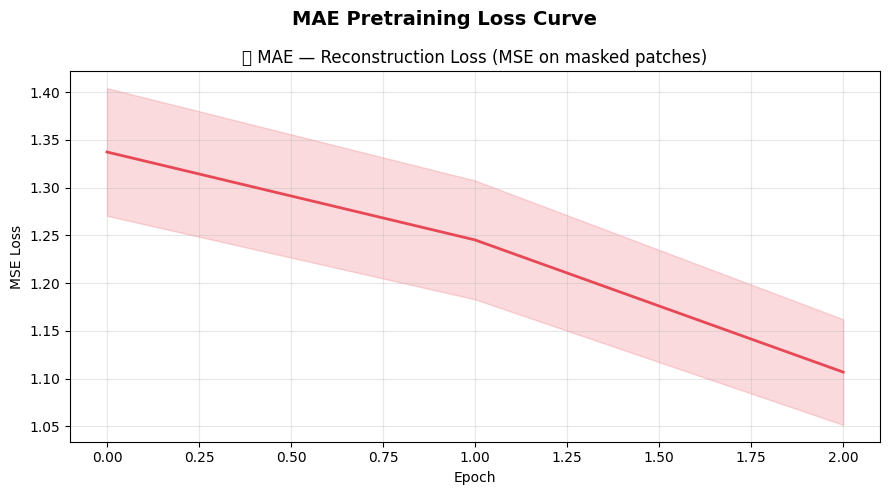


⏱️  Cell executed in 1.74s

⏱️  Cell executed in 1.74s


In [24]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot 1: MAE Pretraining loss curve
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('MAE Pretraining Loss Curve', fontsize=14, fontweight='bold')

ax.plot(mae_losses, color='#E84855', linewidth=2)
ax.fill_between(range(len(mae_losses)),
                [l * 0.95 for l in mae_losses],
                [l * 1.05 for l in mae_losses],
                alpha=0.2, color='#E84855')
ax.set_title('🟠 MAE — Reconstruction Loss (MSE on masked patches)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE Loss')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mae_pretrain_loss.png', dpi=150, bbox_inches='tight')
plt.show()


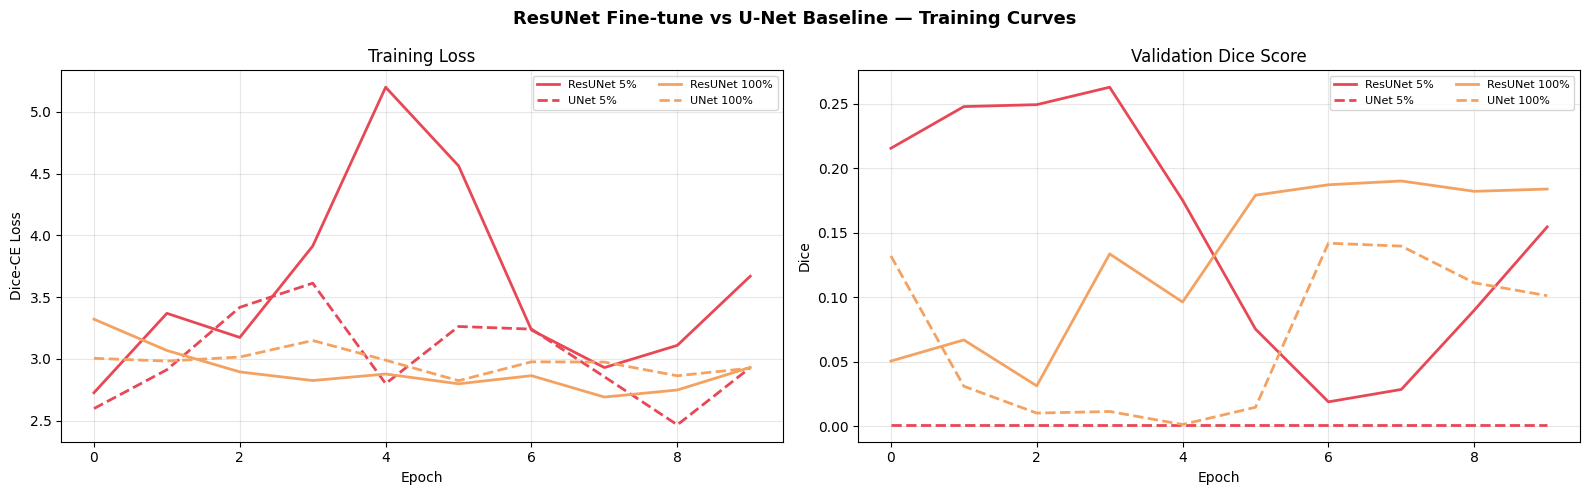


⏱️  Cell executed in 0.49s

⏱️  Cell executed in 0.49s


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot A: Training curves — ResUNet vs U-Net (all label fractions)
# ─────────────────────────────────────────────────────────────────────────────

COLORS = ['#E84855', '#F4A261', '#2A9D8F', '#264653']
fracs  = finetune_cfg['training']['label_fractions']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('ResUNet Fine-tune vs U-Net Baseline — Training Curves',
             fontsize=13, fontweight='bold')

for frac, col in zip(fracs, COLORS):
    lbl = f'{frac:.0%}'
    axes[0].plot(finetune_results[frac]['train_loss'], color=col, lw=2,       label=f'ResUNet {lbl}')
    axes[0].plot(unet_results[frac]['train_loss'],     color=col, lw=2, ls='--', label=f'UNet {lbl}')
    axes[1].plot(finetune_results[frac]['val_dice'],   color=col, lw=2,       label=f'ResUNet {lbl}')
    axes[1].plot(unet_results[frac]['val_dice'],       color=col, lw=2, ls='--', label=f'UNet {lbl}')

for ax, title, ylabel in zip(axes,
    ['Training Loss', 'Validation Dice Score'],
    ['Dice-CE Loss',  'Dice']):
    ax.set_title(title, fontsize=12); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resunet_vs_unet_curves.png', dpi=150, bbox_inches='tight')
plt.show()


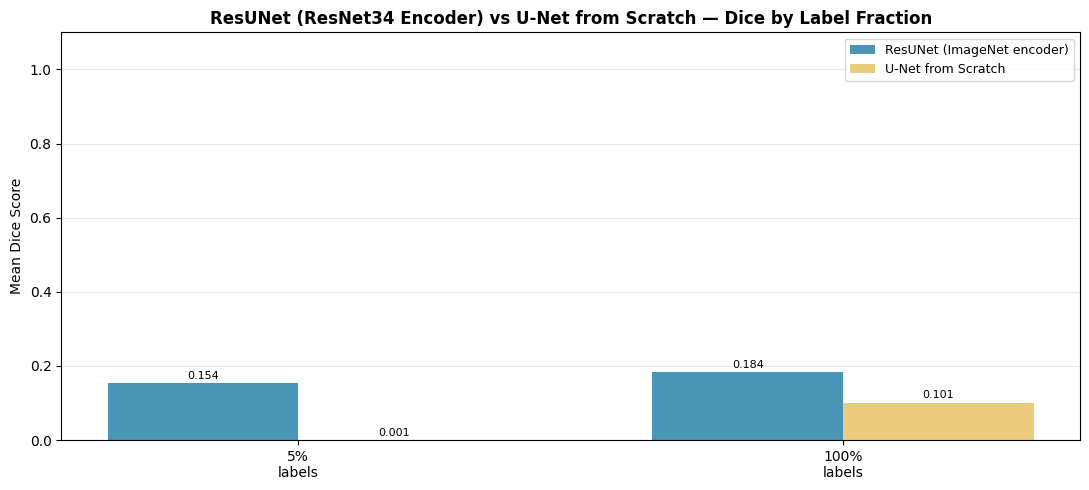

✅ Comparison plots saved.

⏱️  Cell executed in 0.17s

⏱️  Cell executed in 0.17s


In [26]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot B: Grouped bar chart — ResUNet vs U-Net
# ─────────────────────────────────────────────────────────────────────────────

resunet_dices = [eval_results[f]['dice']      for f in fracs]
unet_dices    = [unet_eval_results[f]['dice'] for f in fracs]

x, w = np.arange(len(fracs)), 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w/2, resunet_dices, w, label='ResUNet (ImageNet encoder)', color='#2E86AB', alpha=0.88)
bars2 = ax.bar(x + w/2, unet_dices,    w, label='U-Net from Scratch',         color='#E9C46A', alpha=0.88)

def label_bars(bars, ax):
    for b in bars:
        h = b.get_height()
        ax.annotate(f'{h:.3f}', xy=(b.get_x()+b.get_width()/2, h),
                    xytext=(0,3), textcoords='offset points', ha='center', fontsize=8)

label_bars(bars1, ax); label_bars(bars2, ax)
ax.set_xticks(x); ax.set_xticklabels([f'{f:.0%}\nlabels' for f in fracs])
ax.set_ylabel('Mean Dice Score')
ax.set_title('ResUNet (ResNet34 Encoder) vs U-Net from Scratch — Dice by Label Fraction',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(0, 1.1); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('resunet_vs_unet_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison plots saved.')


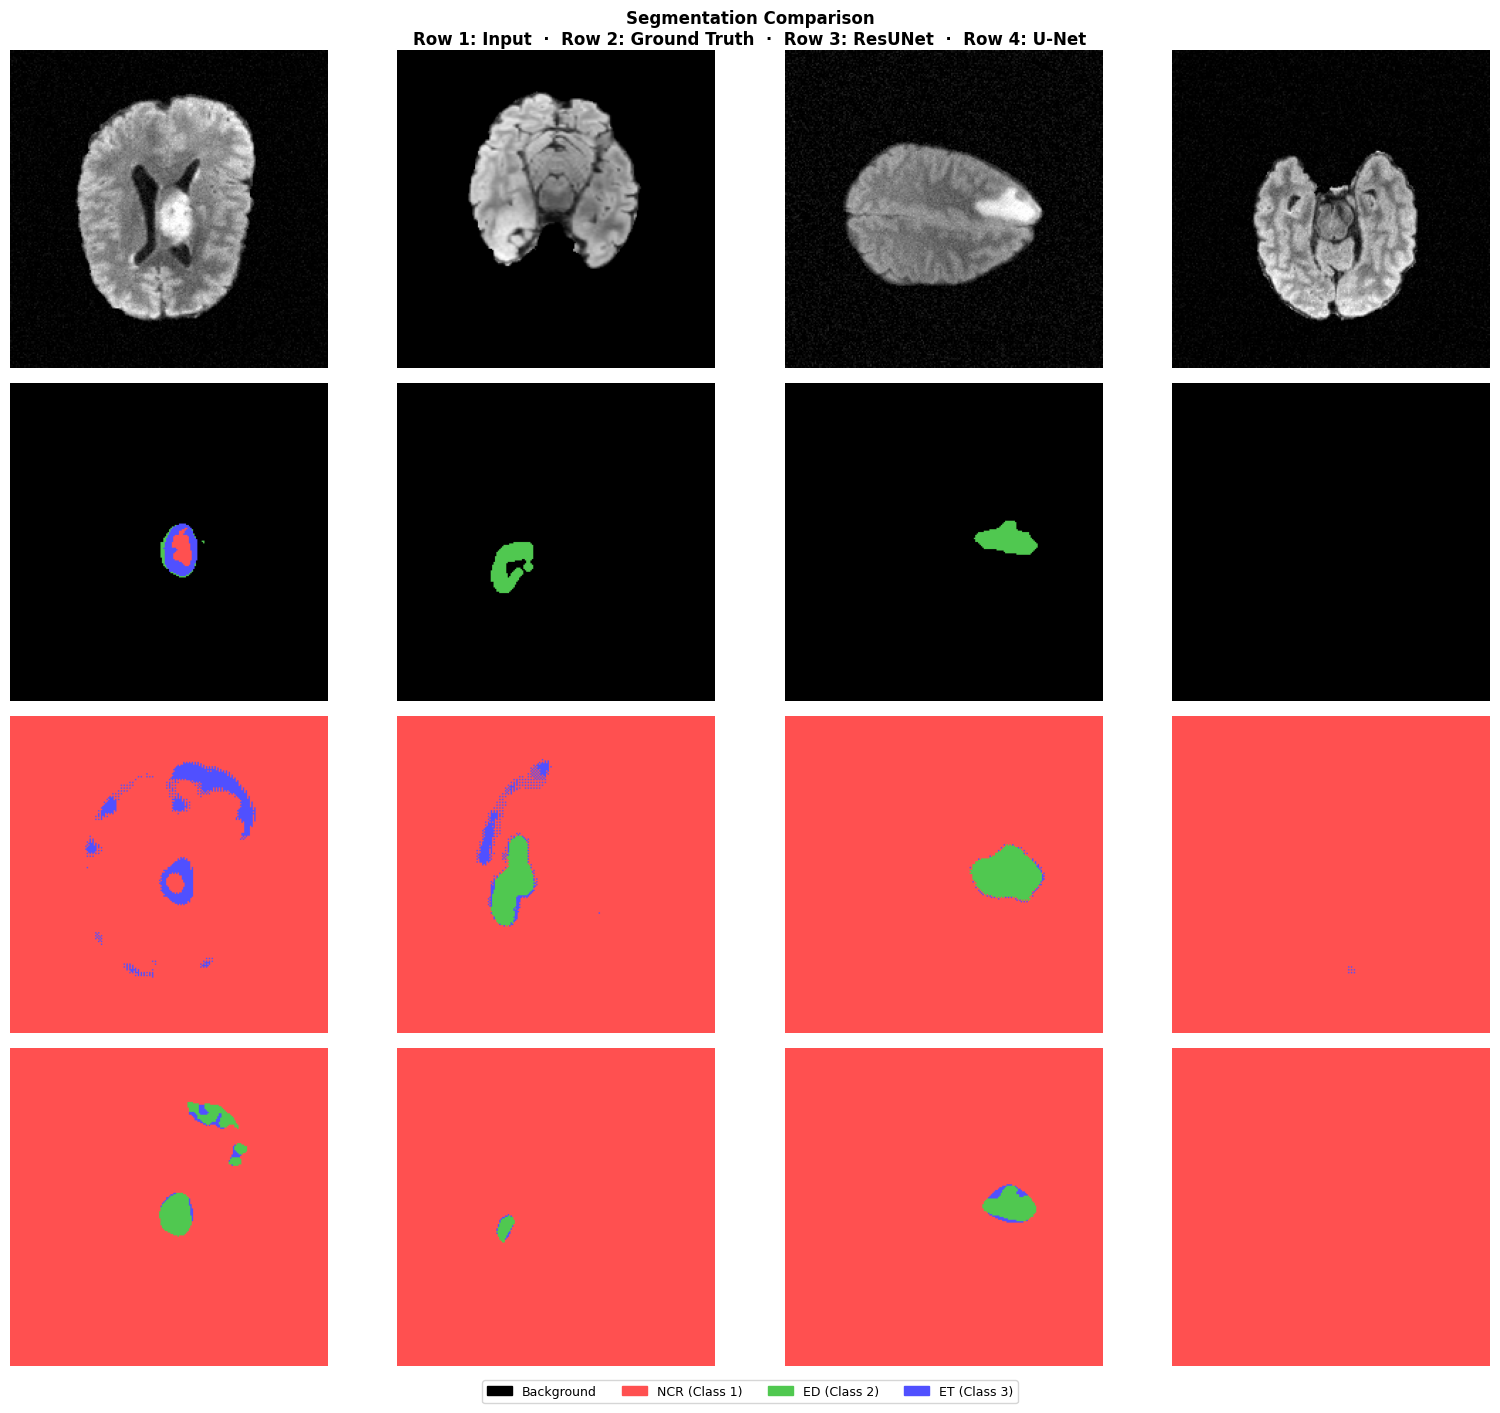

✅ Side-by-side prediction grid saved.

⏱️  Cell executed in 5.55s

⏱️  Cell executed in 5.55s


In [27]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot C: Side-by-side prediction grid — ResUNet vs U-Net
# ─────────────────────────────────────────────────────────────────────────────

seg_model.eval()
unet_model.eval()

PALETTE = np.array([[0,0,0],[255,80,80],[80,200,80],[80,80,255]], dtype=np.uint8)

def mask_to_rgb(mask_np):
    rgb = np.zeros((*mask_np.shape, 3), dtype=np.uint8)
    for c, col in enumerate(PALETTE): rgb[mask_np == c] = col
    return rgb

n_show = 4
fig, axes = plt.subplots(4, n_show, figsize=(16, 14))
fig.suptitle('Segmentation Comparison\n'
             'Row 1: Input  ·  Row 2: Ground Truth  ·  Row 3: ResUNet  ·  Row 4: U-Net',
             fontsize=12, fontweight='bold')

for row, label in enumerate(['Input MRI', 'Ground Truth', 'ResUNet', 'U-Net']):
    axes[row, 0].set_ylabel(label, fontsize=10, fontweight='bold')

with torch.no_grad():
    for col in range(n_show):
        img_t, msk_t = val_ds[col]
        inp = img_t.unsqueeze(0).to(DEVICE)
        resunet_pred = seg_model(inp).argmax(1).squeeze().cpu().numpy()
        unet_pred    = unet_model(inp).argmax(1).squeeze().cpu().numpy()
        img_np = img_t.squeeze().numpy(); msk_np = msk_t.numpy()
        axes[0, col].imshow(img_np,                 cmap='gray')
        axes[1, col].imshow(mask_to_rgb(msk_np))
        axes[2, col].imshow(mask_to_rgb(resunet_pred))
        axes[3, col].imshow(mask_to_rgb(unet_pred))
        for row in range(4): axes[row, col].axis('off')

handles = [plt.Rectangle((0,0),1,1, color=PALETTE[i]/255.) for i in range(4)]
fig.legend(handles, ['Background','NCR (Class 1)','ED (Class 2)','ET (Class 3)'],
           loc='lower center', ncol=4, bbox_to_anchor=(0.5,-0.02), fontsize=9)
plt.tight_layout()
plt.savefig('resunet_vs_unet_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Side-by-side prediction grid saved.')


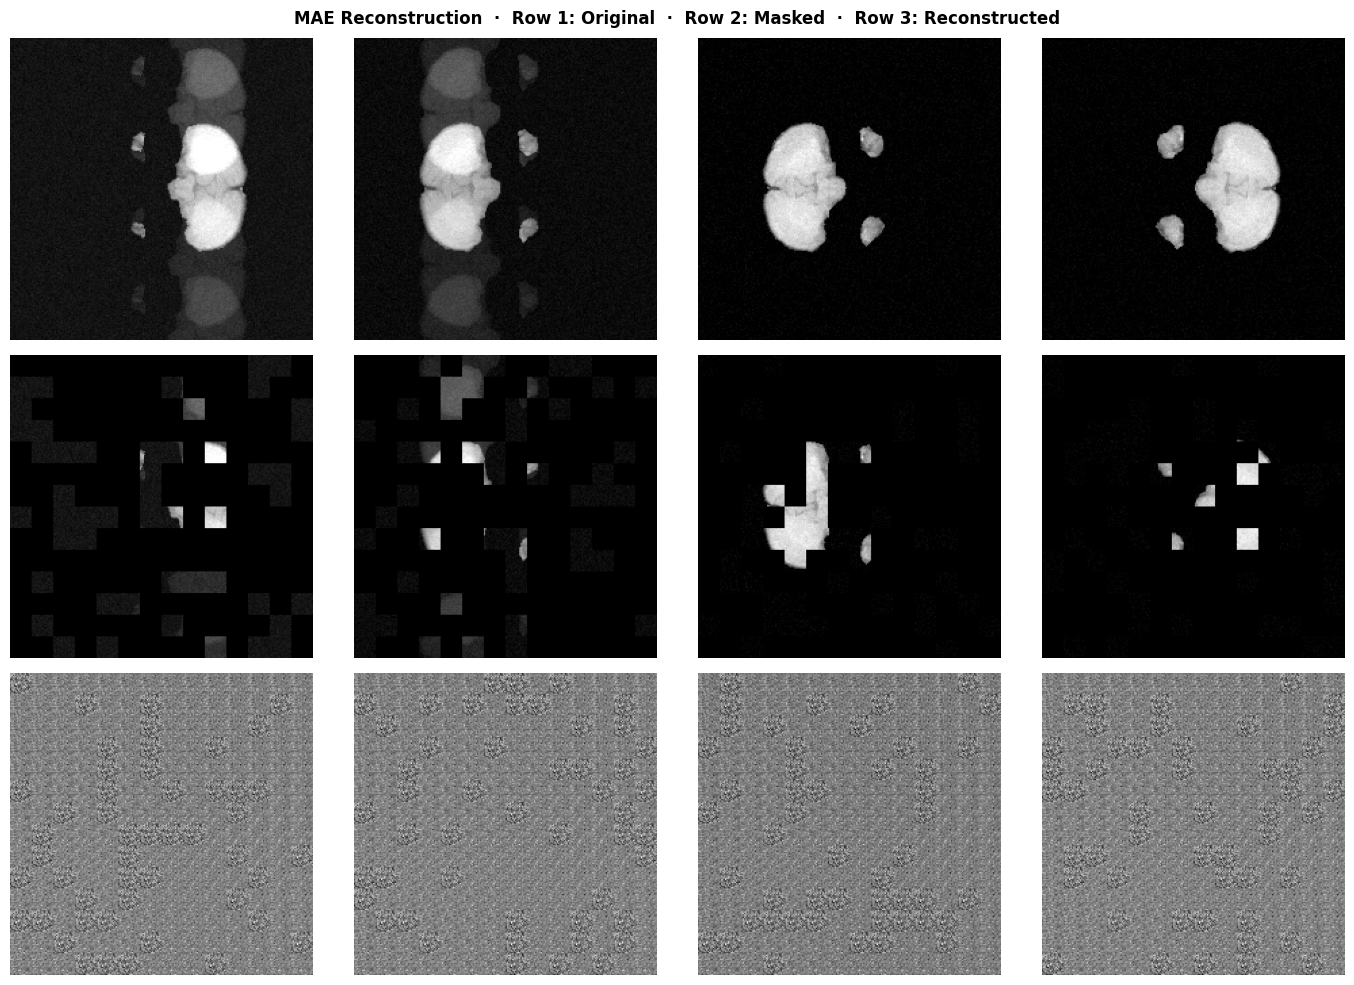


⏱️  Cell executed in 1.75s

⏱️  Cell executed in 1.75s


In [28]:
# ─────────────────────────────────────────────────────────────────────────────
#  Plot 5: MAE reconstruction visualisation
# ─────────────────────────────────────────────────────────────────────────────

mae_model.eval()
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('MAE Reconstruction  ·  Row 1: Original  ·  Row 2: Masked  ·  Row 3: Reconstructed',
             fontsize=12, fontweight='bold')

with torch.no_grad():
    for col in range(4):
        img_t = mae_ds[col].unsqueeze(0).to(DEVICE)
        _, pred_patches = mae_model(img_t)

        _, mask, ids_restore = mae_model.encoder(img_t, mae_model.mask_ratio)

        # Reconstruct masked input (set masked pixels to 0)
        P = mae_cfg_demo['model']['patch_size']
        img_np = img_t.squeeze().cpu().numpy()

        # Mask visualization
        patches = mae_model.patchify(img_t)           # (1,N,P*P)
        G = int(patches.size(1) ** 0.5)
        mask_img = mask[0].cpu().numpy().reshape(G, G)  # (G,G)
        mask_up  = mask_img.repeat(P, axis=0).repeat(P, axis=1)[:img_np.shape[0], :img_np.shape[1]]
        masked_np = img_np.copy()
        masked_np[mask_up.astype(bool)] = 0.

        # Reconstruct full image from decoder output
        pred_np = pred_patches[0].cpu().numpy()   # (N, P*P*C)
        pred_img = pred_np.reshape(G, G, P, P)
        # Normalize to [0,1]
        pred_img = (pred_img - pred_img.min()) / (pred_img.max() - pred_img.min() + 1e-8)
        recon_np = pred_img.transpose(0,2,1,3).reshape(G*P, G*P)[:img_np.shape[0], :img_np.shape[1]]

        axes[0, col].imshow(img_np,    cmap='gray'); axes[0, col].axis('off')
        axes[1, col].imshow(masked_np, cmap='gray'); axes[1, col].axis('off')
        axes[2, col].imshow(recon_np,  cmap='gray'); axes[2, col].axis('off')

row_labels = ['Original', f'Masked ({mae_cfg_demo["model"]["mask_ratio"]:.0%})', 'Reconstructed']
for row, rl in enumerate(row_labels):
    axes[row, 0].set_ylabel(rl, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('mae_reconstructions.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ─────────────────────────────────────────────────────────────────────────────
#  Final Summary Table
# ─────────────────────────────────────────────────────────────────────────────

fracs = finetune_cfg['training']['label_fractions']

print('=' * 60)
print('  FINAL RESULTS — MAE + ResUNet Medical Image Segmentation')
print('=' * 60)
print(f'  SSL Method:    MAE (mask_ratio={mae_cfg["model"]["mask_ratio"]})')
print(f'  Fine-tune:     ResUNet (ResNet34 encoder + U-Net decoder)')
print(f'  Dataset:       BraTS')
print(f'  Num Classes:   {finetune_cfg["model"]["num_classes"]}')
print()
print(f'  {"Label Fraction":>16}  {"Dice":>8}  {"IoU":>8}  {"HD95":>10}')
print('  ' + '-' * 48)
for frac in fracs:
    r = eval_results[frac]
    print(f'  {frac:>15.0%}  {r["dice"]:>8.4f}  {r["iou"]:>8.4f}  {r["hausdorff95"]:>10.2f}')
print('=' * 60)
print('\n✅ Pipeline complete! Checkpoints saved to disk.')
print('   mae_pretrained.pth')
print('   resunet_frac*.pth  •  *.png (figures)')


  FINAL RESULTS — MAE + ResUNet Medical Image Segmentation
  SSL Method:    MAE (mask_ratio=0.75)
  Fine-tune:     ResUNet (ResNet34 encoder + U-Net decoder)
  Dataset:       BraTS
  Num Classes:   4

    Label Fraction      Dice       IoU        HD95
  ------------------------------------------------
               5%    0.1545    0.0837       25.37
             100%    0.1838    0.1012       24.49

✅ Pipeline complete! Checkpoints saved to disk.
   mae_pretrained.pth
   resunet_frac*.pth  •  *.png (figures)

⏱️  Cell executed in 0.00s

⏱️  Cell executed in 0.00s
